In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import pandas as pd

SETUP: Dataset & Preprocessing
Target: Tiny ImageNet (10 Classes)

In [2]:
def get_tiny_imagenet_10(batch_size=64):
    transform = transforms.Compose([
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])

    # Load Full Dataset (Assuming downloaded/extracted locally)
    # If using Kaggle, point to '../input/tiny-imagenet/tiny-imagenet-200/train'
    full_train_dataset = datasets.ImageFolder(root=r"C:/Users/aashv/Downloads/train-20260202T193348Z-3-001/train", transform=transform)
    
    # Select first 10 classes for the experiment
    class_indices = [i for i, (_, label) in enumerate(full_train_dataset.samples) if label < 10]
    subset_train = Subset(full_train_dataset, class_indices)
    
    loader = DataLoader(subset_train, batch_size=batch_size, shuffle=True)
    return loader

QUESTION 3.1: Model Architecture - "Very Deep" FCNN (8+ Layers)

In [3]:
class DeepFCNN(nn.Module):
    def __init__(self, experiment_type='A'):
        super(DeepFCNN, self).__init__()
        self.experiment_type = experiment_type
        self.flatten = nn.Flatten()
        
        layers = []
        input_dim = 3 * 64 * 64 # Tiny ImageNet Flattened
        hidden_dim = 512
        
        # Creating 8 Hidden Layers
        for i in range(8):
            layers.append(nn.Linear(input_dim if i == 0 else hidden_dim, hidden_dim))
            
            if experiment_type == 'A':
                # Experiment A: Sigmoid throughout
                layers.append(nn.Sigmoid())
            else:
                # Experiment B: ReLU + Batch Normalization
                layers.append(nn.BatchNorm1d(hidden_dim))
                layers.append(nn.ReLU())
            
        self.hidden_layers = nn.Sequential(*layers)
        self.output_layer = nn.Linear(hidden_dim, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.hidden_layers(x)
        return self.output_layer(x)

EXPERIMENT EXECUTION & GRADIENT TRACKING

In [4]:
def train_and_track_gradients(experiment_type, num_epochs=5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DeepFCNN(experiment_type=experiment_type).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_loader = get_tiny_imagenet_10()

    grad_norms = []

    print(f"Starting Experiment {experiment_type}...")
    for epoch in range(num_epochs):
        epoch_grads = []
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            # --- Deliverable: Track Gradient Norm of the first layer ---
            # We access the first layer of the Sequential block
            first_layer_weight = model.hidden_layers[0].weight
            if first_layer_weight.grad is not None:
                # Calculate Frobenius norm of gradients for the weight matrix
                grad_norm = first_layer_weight.grad.norm().item()
                epoch_grads.append(grad_norm)

            optimizer.step()
        
        avg_grad = np.mean(epoch_grads)
        grad_norms.append(avg_grad)
        print(f"Epoch [{epoch+1}/{num_epochs}], Avg Grad Norm: {avg_grad:.8f}")

    return grad_norms

In [5]:
# Run both experiments
norms_A = train_and_track_gradients('A')
norms_B = train_and_track_gradients('B')

Starting Experiment A...
Epoch [1/5], Avg Grad Norm: 0.00007518
Epoch [2/5], Avg Grad Norm: 0.17344319
Epoch [3/5], Avg Grad Norm: 0.36927427
Epoch [4/5], Avg Grad Norm: 0.27588266
Epoch [5/5], Avg Grad Norm: 0.23562068
Starting Experiment B...
Epoch [1/5], Avg Grad Norm: 1.61558173
Epoch [2/5], Avg Grad Norm: 0.40903593
Epoch [3/5], Avg Grad Norm: 0.51534230
Epoch [4/5], Avg Grad Norm: 0.59073777
Epoch [5/5], Avg Grad Norm: 0.68200744


DELIVERABLE: PLOTTING

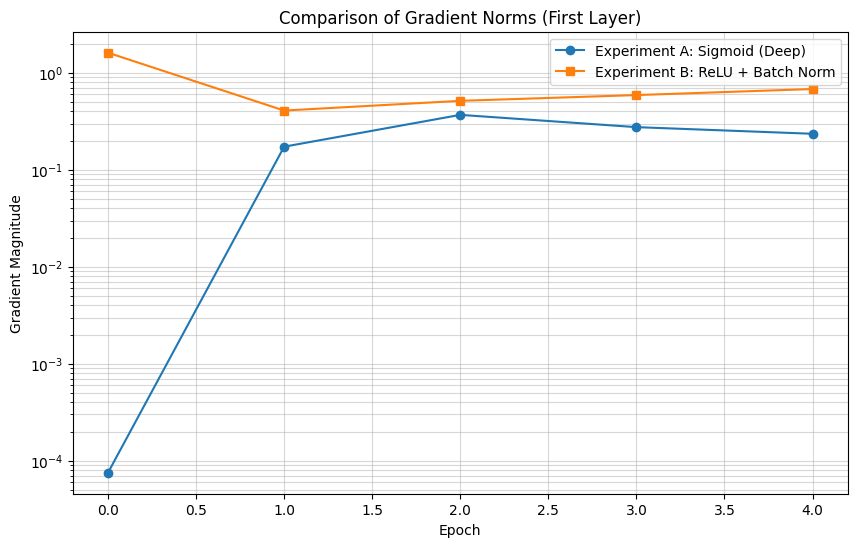

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(norms_A, label='Experiment A: Sigmoid (Deep)', marker='o')
plt.plot(norms_B, label='Experiment B: ReLU + Batch Norm', marker='s')
plt.title('Comparison of Gradient Norms (First Layer)')
plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.yscale('log') # Log scale helps visualize the vanishing gradient clearly
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [7]:
# GLOBALS & PREPARATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Note: train_loader is the same 10-class Tiny ImageNet loader defined in Q3.1
train_loader = get_tiny_imagenet_10() 

In [8]:
# SUPPORTING FUNCTION: train_model
def train_model(model, optimizer, criterion, loader, epochs=3):
    model.train()
    final_acc = 0
    for epoch in range(epochs):
        correct = 0
        total = 0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        final_acc = 100 * correct / total
    return final_acc

In [9]:
# MODEL ARCHITECTURE FOR ABLATION
class AblationFCNN(nn.Module):
    def __init__(self, use_dropout=True):
        super(AblationFCNN, self).__init__()
        layers = []
        input_dim = 3 * 64 * 64
        hidden_dim = 512
        
        for i in range(8):
            layers.append(nn.Linear(input_dim if i == 0 else hidden_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            if use_dropout:
                # Part of the "Switch-Off" test: Dropout can be toggled
                layers.append(nn.Dropout(p=0.2))
                
        self.network = nn.Sequential(*layers)
        self.output = nn.Linear(hidden_dim, 10)

    def forward(self, x):
        return self.output(self.network(x.view(x.size(0), -1)))

In [10]:
# EXECUTION: THE SWITCH-OFF TEST
def run_ablation_study(train_loader):
    configs = [
        {"name": "Baseline (Adam, LR=0.001, Dropout)", "lr": 0.001, "opt": "Adam", "dropout": True},
        {"name": "1. Remove Dropout", "lr": 0.001, "opt": "Adam", "dropout": False},
        {"name": "2a. LR Factor x10 (0.01)", "lr": 0.01, "opt": "Adam", "dropout": True},
        {"name": "2b. LR Factor /10 (0.0001)", "lr": 0.0001, "opt": "Adam", "dropout": True},
        {"name": "3. Switch to Vanilla SGD", "lr": 0.001, "opt": "SGD", "dropout": True},
    ]

    results = []

    for cfg in configs:
        print(f"Running: {cfg['name']}...")
        model = AblationFCNN(use_dropout=cfg['dropout']).to(device)
        criterion = nn.CrossEntropyLoss()
        
        if cfg['opt'] == "Adam":
            optimizer = optim.Adam(model.parameters(), lr=cfg['lr'])
        else:
            optimizer = optim.SGD(model.parameters(), lr=cfg['lr'])

        acc = train_model(model, optimizer, criterion, train_loader, epochs=3)
        results.append({"Experiment": cfg['name'], "Final Accuracy": f"{acc:.2f}%"})

    #Delivering the Summary Table via DataFrame
    df = pd.DataFrame(results)
    print("\n--- FINAL ABLATION SUMMARY TABLE ---")
    print(df.to_string(index=False))
    return df

In [11]:
if __name__ == "__main__":
    train_loader = get_tiny_imagenet_10()
    
    run_ablation_study(train_loader)

Running: Baseline (Adam, LR=0.001, Dropout)...
Running: 1. Remove Dropout...
Running: 2a. LR Factor x10 (0.01)...
Running: 2b. LR Factor /10 (0.0001)...
Running: 3. Switch to Vanilla SGD...

--- FINAL ABLATION SUMMARY TABLE ---
                        Experiment Final Accuracy
Baseline (Adam, LR=0.001, Dropout)         38.31%
                 1. Remove Dropout         42.77%
          2a. LR Factor x10 (0.01)         30.40%
        2b. LR Factor /10 (0.0001)         30.29%
          3. Switch to Vanilla SGD         13.66%
